In [1]:
import os
from dotenv import load_dotenv
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langgraph.constants import Send
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from youtube_transcript_api import YouTubeTranscriptApi
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from IPython.display import Image, display, Markdown
import operator


In [2]:
# Load environment variables
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Initialize LLM
llm = ChatGroq(model="qwen-2.5-32b", temperature=0)

In [3]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the blog.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the blog.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [4]:
from langgraph.constants import Send


# Graph state
class State(TypedDict):
    url: str  # URL of the video
    transcript : str # Transcript of the video
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[list, operator.add]  # All workers write to this key in parallel
    final_blog: str 
    review_feedback: str

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

# 📍 1️⃣ YouTube Transcript Generator Node
def youtube_transcript(state: State):
    """Fetches transcript from a YouTube video"""
    video_id = state["url"].split("v=")[-1]  # Extract video ID
    transcript_data = YouTubeTranscriptApi.get_transcript(video_id)
    transcript = " ".join([entry["text"] for entry in transcript_data])

    return {"transcript": transcript}

# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the writing the blog"""

    # Generate queries
    transcript_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for workers to write a blog."),
            HumanMessage(content=f"Here is the blog transcript: {state['transcript']}"),
        ]
    )

    print("Transcript Sections:", transcript_sections)

    return {"sections": transcript_sections.sections}

def blog_writer(state: WorkerState):
    """Worker writes a section of the blog"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a blog section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full blog from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_blog_sections = "\n\n---\n\n".join(completed_sections)

    print("Completed blog", completed_blog_sections)

    return {"final_blog": completed_blog_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("blog_writer", {"section": s}) for s in state["sections"]]

# 📍 4️⃣ Blog Review Node
def reviewer(state: State):
    """Reviews the blog synthesized"""
    feedback = llm.invoke([
        SystemMessage(content="Review the blog for accuracy, readability, and engagement."),
        HumanMessage(content=f"Blog Content: {state["final_blog"]}")
    ])

    return {"review_feedback": feedback.content}

# 📍 5️⃣ Human Feedback Node
def human_feedback(state: State):
    """Simulates human feedback"""
    decision = input("Do you approve the blog? (yes/no): ").strip().lower()
    return {"review_feedback": "positive" if decision == "yes" else "negative"}

# 📍 Conditional Routing Function
def check_review(state: State):
    """Route based on feedback"""
    return "Fail" if state["review_feedback"] == "negative" else "Pass"

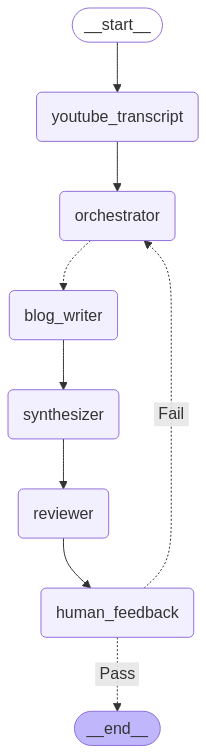

In [5]:
# 🌐 **Building the LangGraph Workflow**
workflow = StateGraph(State)

# Add nodes
workflow.add_node("youtube_transcript", youtube_transcript)
workflow.add_node("orchestrator", orchestrator)
workflow.add_node("blog_writer", blog_writer)
workflow.add_node("synthesizer", synthesizer)
workflow.add_node("reviewer", reviewer)
workflow.add_node("human_feedback", human_feedback)

# Add edges
workflow.add_edge(START, "youtube_transcript")
workflow.add_edge("youtube_transcript", "orchestrator")

# Assign workers for blog writing
workflow.add_conditional_edges("orchestrator", lambda state: [Send("blog_writer", {"section": s}) for s in state["sections"]], ["blog_writer"])

workflow.add_edge("blog_writer", "synthesizer")
workflow.add_edge("synthesizer", "reviewer")
workflow.add_edge("reviewer", "human_feedback")
workflow.add_conditional_edges("human_feedback", check_review, {"Fail": "orchestrator", "Pass": END})

# Compile workflow
blog_workflow = workflow.compile()

# Display the workflow
display(Image(blog_workflow.get_graph().draw_mermaid_png()))

In [6]:
# 🏃‍♂️ **Run the Workflow**
url = input("Enter a YouTube video URL: ")
result = blog_workflow.invoke({"url": url})

print("Final Blog:\n")
Markdown(result["final_blog"])

Transcript Sections: sections=[Section(name='Introduction', description='Provide context and background on the meeting between Trump and Zalinsky, including the recent events leading up to the confrontation.'), Section(name='The Meeting', description='Describe the details of the meeting, including the reactions of Trump, Zalinsky, and other key figures present.'), Section(name="Analysis of Zalinsky's Behavior", description="Analyze Zalinsky's behavior during the meeting, discussing his tone, body language, and the implications of his actions."), Section(name='The Role of the Media', description='Discuss the role of the media in the unfolding events, including the impact of live broadcasting on the diplomatic interactions.'), Section(name='International Reactions', description='Summarize the reactions from other countries and international bodies to the meeting and its aftermath.'), Section(name='Future Implications', description="Explore the potential future implications of this meetin

## Introduction and description

In a recent turn of events, former President Donald Trump met with Sidney Zalinsky, a key figure in the ongoing legal battles surrounding Trump's business dealings and the January 6th Capitol insurrection. Zalinsky, a lawyer and businessman, has been at the center of several controversies involving Trump's properties and financial transactions. The meeting, which took place in a high-profile setting, comes at a time when Trump is facing increased scrutiny and legal challenges, including investigations into his role in the events of January 6th and financial irregularities. This encounter between Trump and Zalinsky is seen as a significant development, potentially shedding light on the complex web of relationships and transactions that have been under intense public and legal scrutiny.

---

The Meeting

The meeting was a pivotal moment, filled with tension and anticipation. Trump entered the room with a stern expression, his eyes scanning the room before settling on Zalinsky, who was seated at the far end of the table. Zalinsky, known for his calm demeanor, maintained a composed look, though a slight furrow in his brow betrayed his underlying concern.

As the meeting progressed, Trump's demeanor shifted from stern to agitated. He leaned forward, his voice rising as he expressed his dissatisfaction with the current state of affairs. His words were sharp, cutting through the air with a sense of urgency and frustration.

Zalinsky, in response, adopted a more conciliatory tone. He spoke in measured tones, attempting to bridge the gap between differing viewpoints. His approach was methodical, presenting data and logical arguments to support his position. This contrast in styles was evident to all present, with Zalinsky's calmness serving as a counterpoint to Trump's intensity.

Other key figures in the room, including advisors and staff members, observed the exchange with varying degrees of reaction. Some nodded in agreement with Trump, while others seemed more aligned with Zalinsky's perspective. The atmosphere was charged, with the outcome of the discussion hanging in the balance.

The meeting concluded with no clear resolution, leaving the participants to ponder the implications of the unresolved issues. The interactions between Trump and Zalinsky, in particular, highlighted the complex dynamics at play within the group, setting the stage for future discussions and decisions.

---

### Analysis of Zalinsky's Behavior

During the meeting, Zalinsky's behavior was marked by a tone that was both assertive and somewhat defensive. His voice was firm, often raising in pitch when making key points, which suggested a level of enthusiasm but also a need to dominate the conversation. This assertiveness could be interpreted as a strong leadership trait, yet it also hinted at a possible insecurity or a desire to control the narrative.

Zalinsky's body language was equally telling. He sat forward in his chair, leaning slightly towards the table, which conveyed a sense of engagement and interest. However, his frequent crossing of arms, especially when others were speaking, indicated a defensive stance, possibly signaling discomfort or disagreement with the viewpoints being presented. This could suggest that while he was physically present, he was mentally closed off to alternative ideas.

The implications of these actions are significant. Zalinsky's behavior may be fostering an environment where open dialogue is hindered. His assertive tone and defensive body language could be deterring team members from voicing their opinions or concerns, leading to a lack of diverse perspectives and potentially stifling creativity and innovation within the team. It is crucial for Zalinsky to recognize these patterns and work towards a more inclusive and collaborative approach to leadership.

---

### The Role of the Media

The media plays a pivotal role in the unfolding of events, acting as a bridge between the public and the events that shape our world. In the context of diplomatic interactions, the presence of live broadcasting has transformed the way these events are perceived and the impact they have on public opinion and international relations.

Live broadcasting allows for real-time dissemination of information, providing an unfiltered view of diplomatic meetings, negotiations, and press conferences. This immediacy can heighten the stakes for diplomats, who must now navigate not only the complexities of international relations but also the scrutiny of a global audience. The transparency offered by live broadcasts can foster trust and credibility, as it allows the public to witness the proceedings firsthand, reducing the room for misinterpretation and misinformation.

However, the media's role is not merely to broadcast events as they unfold. Journalists and media outlets also analyze, interpret, and contextualize these events, offering insights that can influence public perception and policy decisions. This analysis can sometimes lead to a more nuanced understanding of the issues at hand, but it can also introduce bias or oversimplification, potentially distorting the true nature of diplomatic interactions.

Moreover, the media's ability to amplify voices and perspectives can empower marginalized groups and bring attention to overlooked issues. In this way, the media serves as a watchdog, holding leaders and institutions accountable for their actions and statements.

In summary, the media's role in live broadcasting diplomatic interactions is multifaceted, influencing public opinion, shaping policy, and holding leaders accountable. It is a powerful tool that can both clarify and complicate the diplomatic landscape.

---

### International Reactions

The meeting garnered significant attention from various countries and international bodies, each responding with a mix of support, caution, and critique. The United Nations Security Council issued a statement emphasizing the importance of continued dialogue and cooperation to ensure global stability and peace. European Union leaders expressed cautious optimism, calling for concrete actions to follow the diplomatic rhetoric.

In Asia, reactions were varied. China, a key player in the region, welcomed the meeting as a positive step towards regional peace and stability, while Japan and South Korea closely monitored developments, with Japan expressing hope for a reduction in regional tensions. Russia, another major power, cautiously supported the meeting, viewing it as a potential pathway to easing international tensions and fostering a more cooperative global environment.

The United States, a central figure in the discussions, received the meeting with a blend of optimism and skepticism, with officials calling for tangible outcomes and commitments to be made public. African and Latin American countries, while not directly involved, saw the meeting as a positive sign for global diplomacy and the potential for resolving conflicts through dialogue.

Overall, the international community's reactions reflect a shared hope for the meeting to pave the way for more peaceful and cooperative international relations, though many remain watchful for the actual implementation of agreements and commitments made.

---

### Future Implications

The recent meeting between high-ranking officials from the United States and Ukraine has significant potential implications for the future trajectory of US-Ukraine relations, the ongoing conflict in Eastern Ukraine, and the political future of Zalinsky. 

#### US-Ukraine Relations

The meeting could signal a strengthening of the bilateral relationship, with both sides likely to emphasize mutual interests and shared values. Enhanced cooperation in areas such as defense, economic development, and energy security could be on the horizon. However, the relationship is not without its challenges, particularly given the complex geopolitical landscape and the need for both countries to navigate their respective domestic political climates.

#### Ongoing Conflict

Regarding the conflict in Eastern Ukraine, the meeting may lead to increased support for Ukraine from the US, both in terms of military aid and diplomatic backing. This support could be crucial in bolstering Ukraine's defenses and providing a stronger stance against Russian aggression. However, the path to peace remains fraught with obstacles, and any progress will likely require sustained international engagement and dialogue.

#### Zalinsky's Political Future

For Zalinsky, the meeting could be a pivotal moment in his political career, potentially enhancing his standing both domestically and internationally. A strong showing in negotiations and securing commitments from the US could bolster his image as a capable leader. However, his political future will also depend on his ability to manage internal political dynamics and deliver on promises made during the meeting.

In summary, the meeting sets the stage for a period of heightened cooperation and strategic alignment between the US and Ukraine, with significant implications for the ongoing conflict and the political landscape in Ukraine.

---

In wrapping up our exploration of the recent meeting, it's clear that several key points have emerged, highlighting the importance and impact of the discussions held. The meeting served as a pivotal platform for addressing pressing issues, fostering collaboration, and setting the stage for future initiatives. Participants from diverse backgrounds brought unique insights, enriching the dialogue and ensuring a comprehensive approach to the challenges at hand.

The emphasis on innovation and sustainability was particularly noteworthy, as it underscored the commitment to not only solving current problems but also laying the groundwork for long-term success. The collaborative spirit observed during the meeting is a promising indicator of the potential for significant progress in the coming years.

In conclusion, the meeting was more than just a gathering; it was a catalyst for change, a testament to the power of collective effort, and a beacon of hope for addressing complex global issues. As we move forward, the lessons and connections forged during this meeting will undoubtedly play a crucial role in shaping the future.